   polarity                                               text
0         0  @switchfoot http://twitpic.com/2y1zl - Awww, t...
1         0  is upset that he can't update his Facebook by ...
2         0  @Kenichan I dived many times for the ball. Man...
3         0    my whole body feels itchy and like its on fire 
4         0  @nationwideclass no, it's not behaving at all....
polarity
0    800000
1    800000
Name: count, dtype: int64
                                                text  \
0  @switchfoot http://twitpic.com/2y1zl - Awww, t...   
1  is upset that he can't update his Facebook by ...   
2  @Kenichan I dived many times for the ball. Man...   
3    my whole body feels itchy and like its on fire    
4  @nationwideclass no, it's not behaving at all....   

                                          clean_text  
0  @switchfoot http://twitpic.com/2y1zl - awww, t...  
1  is upset that he can't update his facebook by ...  
2  @kenichan i dived many times for the ball. man...  
3    m

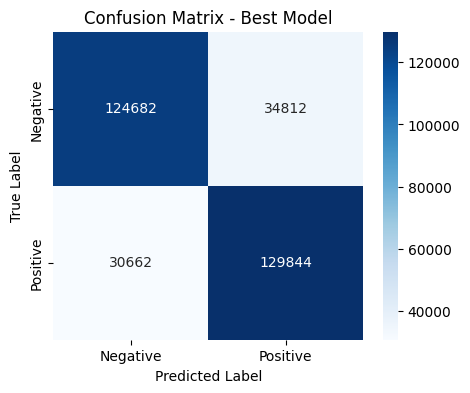

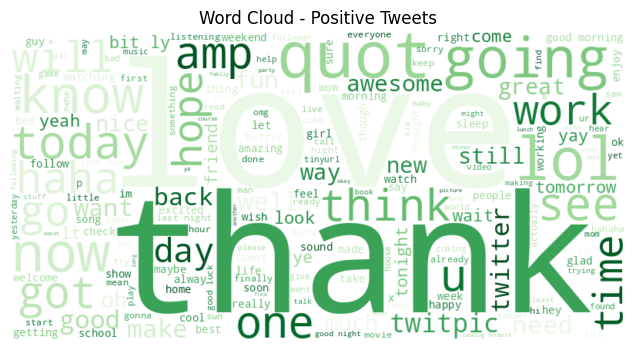

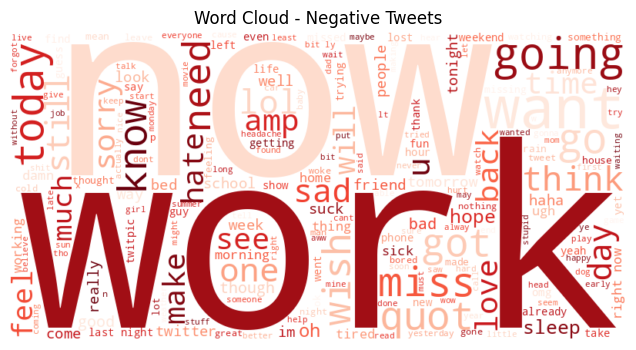

In [10]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import BernoulliNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# ---------- Load Data ----------
df = pd.read_csv('/content/training.1600000.processed.noemoticon.csv',
                  encoding='latin-1', header=None, engine='python', on_bad_lines='skip')
df = df[[0, 5]]
df.columns = ['polarity', 'text']
print(df.head())

# ---------- Clean Labels ----------
df = df[df.polarity != 2]
df['polarity'] = df['polarity'].map({0: 0, 4: 1})
print(df['polarity'].value_counts())

# ---------- Clean Text ----------
def clean_text(text):
    return text.lower()

df['clean_text'] = df['text'].apply(clean_text)
print(df[['text', 'clean_text']].head())

# ---------- Train/Test Split ----------
X_train, X_test, y_train, y_test = train_test_split(
    df['clean_text'], df['polarity'], test_size=0.2, random_state=42
)
print("Train size:", len(X_train))
print("Test size:", len(X_test))

# ---------- TF-IDF Vectorization ----------
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)
print("TF-IDF shape (train):", X_train_tfidf.shape)
print("TF-IDF shape (test):", X_test_tfidf.shape)

# ---------- Model 1: Bernoulli Naive Bayes ----------
bnb = BernoulliNB()
bnb.fit(X_train_tfidf, y_train)
bnb_pred = bnb.predict(X_test_tfidf)
print("\nBernoulli Naive Bayes Accuracy:", accuracy_score(y_test, bnb_pred))
print("BernoulliNB Classification Report:\n", classification_report(y_test, bnb_pred))

# ---------- Model 2: Logistic Regression ----------
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_tfidf, y_train)
lr_pred = lr.predict(X_test_tfidf)
print("\nLogistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print("Logistic Regression Classification Report:\n", classification_report(y_test, lr_pred))

# ---------- Model 3: Linear SVM ----------
svm = LinearSVC()
svm.fit(X_train_tfidf, y_train)
svm_pred = svm.predict(X_test_tfidf)
print("\nLinear SVM Accuracy:", accuracy_score(y_test, svm_pred))
print("Linear SVM Classification Report:\n", classification_report(y_test, svm_pred))

# ---------- Model Comparison ----------
results = pd.DataFrame({
    'Model': ['Bernoulli Naive Bayes', 'Logistic Regression', 'Linear SVM'],
    'Accuracy': [
        accuracy_score(y_test, bnb_pred),
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, svm_pred)
    ]
})
print("\nModel Comparison:\n", results.sort_values('Accuracy', ascending=False))

# ---------- Sample Predictions ----------
sample_tweets = ["I love this!", "I hate that!", "It was okay, not great."]
sample_vec = vectorizer.transform(sample_tweets)
print("\nSample Predictions:")
print("BernoulliNB:", bnb.predict(sample_vec))
print("Logistic Regression:", lr.predict(sample_vec))
print("Linear SVM:", svm.predict(sample_vec))

# ---------- Confusion Matrix (best model: choose based on results above) ----------
cm = confusion_matrix(y_test, lr_pred)  # change lr_pred to bnb_pred/svm_pred if a different model wins
labels = ['Negative', 'Positive']
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix - Best Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# ---------- Word Clouds ----------
positive_tweets = " ".join(df[df['polarity'] == 1]['clean_text'].values)
negative_tweets = " ".join(df[df['polarity'] == 0]['clean_text'].values)

wordcloud_pos = WordCloud(width=800, height=400, background_color='white', colormap='Greens').generate(positive_tweets)
plt.figure(figsize=(8, 4))
plt.imshow(wordcloud_pos, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud - Positive Tweets')
plt.show()

wordcloud_neg = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(negative_tweets)
plt.figure(figsize=(8, 4))
plt.imshow(wordcloud_neg, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud - Negative Tweets')
plt.show()